In [1]:
import numpy as np
import nbodykit


In [2]:
lin_modes_sim = np.load("./tau_mesh_red_CRO512.npy")
flux_sim = np.exp(-lin_modes_sim)
delta_flux_sim = flux_sim/np.mean(flux_sim)-1

delta_flux_ex = np.load("example_gen_field.npy")

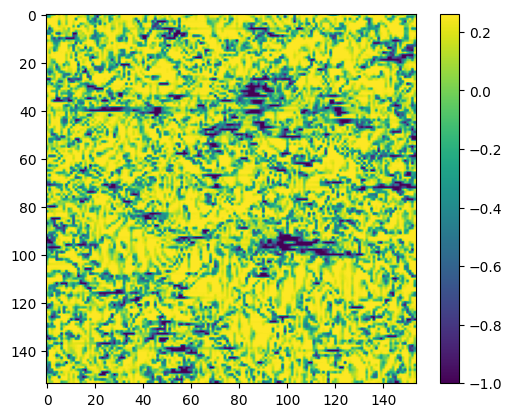

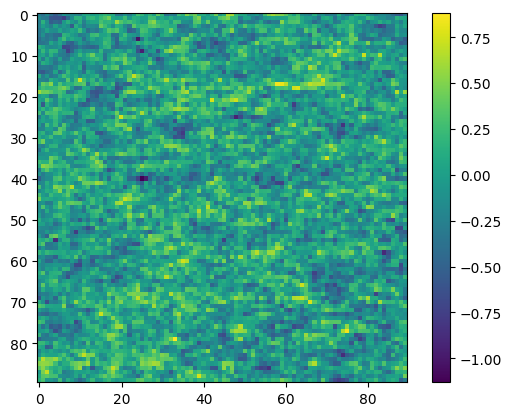

In [3]:
# %pylab inline
import matplotlib.pyplot as plt
plt.imshow(delta_flux_sim[0])
plt.colorbar()
plt.show()

plt.imshow(delta_flux_ex[0])
plt.colorbar()
plt.show()

In [4]:
#looks different, but that isn't a huge suprise... lets see what the ps looks like!

In [5]:
from nbodykit.lab import UniformCatalog, FFTPower
#calculate fluxes, do things in flux space
pm_red = nbodykit.source.mesh.array.ArrayMesh(delta_flux_sim, 150)
pm_ex = nbodykit.source.mesh.array.ArrayMesh(delta_flux_ex, 150)



In [8]:
poles_red

<BinnedStatistic: dims: (k: 32, mu: 5), variables: ('k', 'mu', 'power', 'modes')>

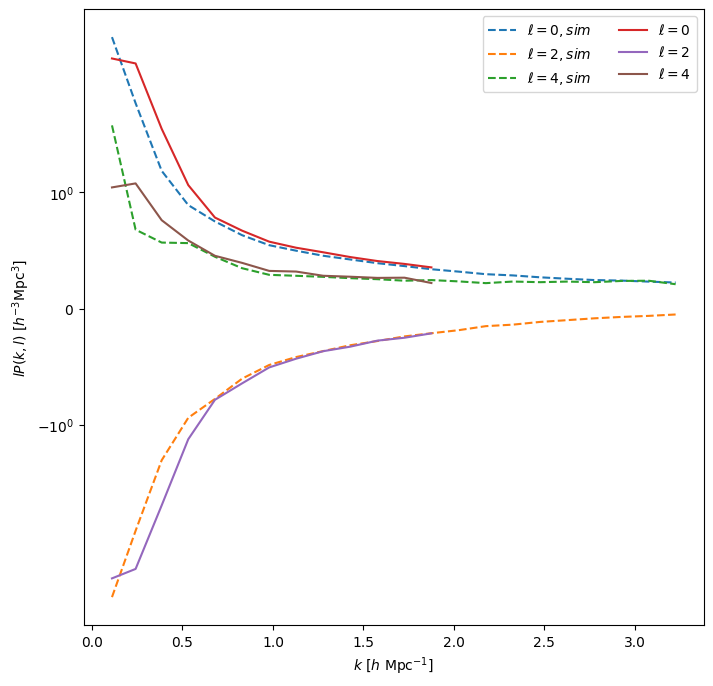

In [15]:
r_red_2d = FFTPower(pm_red, mode='2d', dk=0.15, kmin=0.0001, Nmu=5, los=[0,0,1], poles=[0,2,4])
poles_red = r_red_2d.poles

r_ex_2d = FFTPower(pm_ex, mode='2d', dk=0.15, kmin=0.0001, Nmu=5, los=[0,0,1], poles=[0,2,4])
poles_ex = r_ex_2d.poles
plt.figure(figsize=(8,8))

# plot each mu bin
lines = ["r","g","b","k","y"]
for ell in [0,2,4]:
    label = r'$\ell=%d,sim$' % (ell)
    P = poles_red['power_%d' %ell].real
    # if ell == 0: P = P - poles.attrs['shotnoise']
    plt.plot(poles_red['k'], poles_red['k'] * P, label=label,linestyle='dashed')

# format the axes
plt.xlabel(r"$k$ [$h \ \mathrm{Mpc}^{-1}$]")
plt.ylabel(r"$lP(k, l)$ [$h^{-3}\mathrm{Mpc}^3$]")

#plot realspace as little dots on top
for ell in [0,2,4]:
    label = r'$\ell=%d$' % (ell)
    P = poles_ex['power_%d' %ell].real
    # if ell == 0: P = P - poles.attrs['shotnoise']
    plt.plot(poles_ex['k'], poles_ex['k'] * P, label=label)

plt.legend(loc=0, ncol=2)

plt.yscale("symlog")


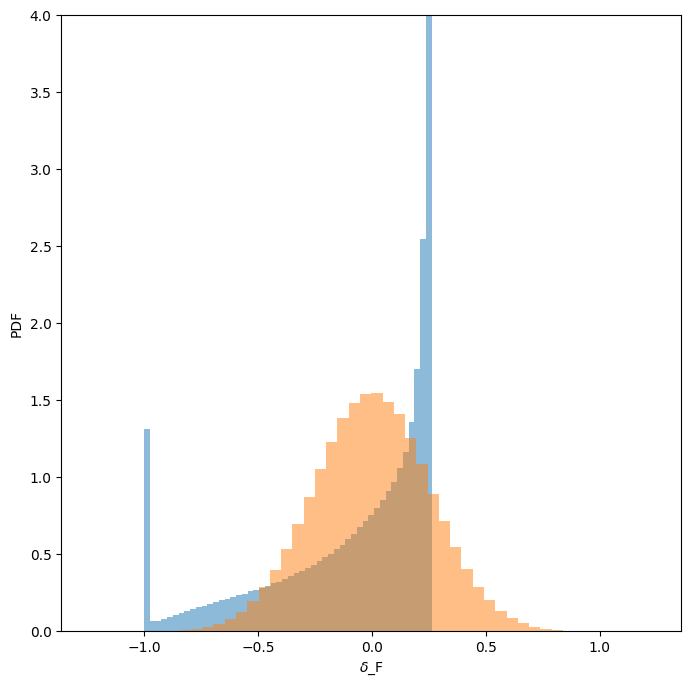

In [21]:
plt.figure(figsize=(8,8))
plt.hist(delta_flux_sim.ravel(),alpha=0.5,density=True,bins=50,label=r"$\delta_F,sim$")
plt.hist(delta_flux_ex.ravel(),alpha=0.5,density=True,bins=50,label=r"$\delta_F$")
plt.ylim(ymax=4)
plt.xlabel("$\delta$_F")
plt.ylabel("PDF")
plt.show()